In [21]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl

In [22]:
def get_lat_weights(latitude_values):
    lat_rad = np.deg2rad(latitude_values)
    weights = np.cos(lat_rad)
    return weights / np.mean(weights)

In [23]:
class Normalizer:
    def __init__(self):
        self.mean_in, self.std_in = None, None
        self.mean_out, self.std_out = None, None

    def set_input_statistics(self, mean, std):
        self.mean_in = mean
        self.std_in = std

    def set_output_statistics(self, mean, std):
        self.mean_out = mean
        self.std_out = std

    def normalize(self, data, data_type):
        if data_type == "input":
            return (data - self.mean_in) / self.std_in
        elif data_type == "output":
            return (data - self.mean_out) / self.std_out

    def inverse_transform_output(self, data):
        return data * self.std_out + self.mean_out

In [24]:
class ClimateDataset(Dataset):
    def __init__(self, inputs_dask, outputs_dask, output_is_normalized=True):
        self.size = inputs_dask.shape[0]
        print(f"Creating dataset with {self.size} samples...")

        inputs_np = inputs_dask.compute()
        outputs_np = outputs_dask.compute()

        self.inputs = torch.from_numpy(inputs_np).float()
        self.outputs = torch.from_numpy(outputs_np).float()

        if torch.isnan(self.inputs).any() or torch.isnan(self.outputs).any():
            raise ValueError("NaNs found in dataset")

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        return self.inputs[idx], self.outputs[idx]

In [25]:
path = "processed_data_cse151b_v2_corrupted_ssp245/processed_data_cse151b_v2_corrupted_ssp245.zarr"
input_vars = ["CO2", "SO2", "CH4", "BC", "rsdt"]
output_vars = ["tas", "pr"]
train_ssps = ["ssp126", "ssp370", "ssp585"]
test_ssp = "ssp245"
target_member_id = 0
val_split = 0.1
test_months = 360
batch_size = 32
num_workers = 0
seed = 42
normalizer = Normalizer()

In [26]:
ds = xr.open_zarr(path, consolidated=False, chunks={"time": 24})
spatial_template = ds["rsdt"].isel(time=0, ssp=0, drop=True)
lat = spatial_template.y.values
lon = spatial_template.x.values
area_weights = xr.DataArray(get_lat_weights(lat), dims=["y"], coords={"y": lat})

ds

<xarray.Dataset> Size: 621MB
Dimensions:    (longitude: 72, y: 48, member_id: 3, ssp: 4, time: 1021,
                latitude: 48, x: 72)
Coordinates:
  * longitude  (longitude) float64 576B 1.25 6.25 11.25 ... 346.2 351.2 356.2
  * y          (y) float64 384B -88.59 -84.82 -81.05 ... 81.05 84.82 88.59
  * member_id  (member_id) int64 24B 0 1 2
  * ssp        (ssp) <U6 96B 'ssp126' 'ssp245' 'ssp370' 'ssp585'
  * latitude   (latitude) float64 384B -89.05 -85.26 -81.47 ... 85.26 89.05
  * x          (x) float64 576B 1.875 6.875 11.88 16.88 ... 346.9 351.9 356.9
  * time       (time) object 8kB 2015-01-15 00:00:00 ... 2100-01-15 00:00:00
    lat        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
    lon        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
Data variables:
    SO2        (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    CH4        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
    pr         (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
    tas        (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
    BC         (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    rsdt       (ssp, time, y, x) float32 56MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    CO2        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
Attributes:
    original_member_ids:  ['r10i1p1f1', 'r11i1p1f1', 'r4i1p1f1']
    precipitation_units:  mm/day (converted from kg m-2 s-1)
    source:               CMIP6 data processed for CSE151B
    ssp:                  ssp126

In [27]:
def load_ssp(ssp):
    input_dask, output_dask = [], []
    for var in input_vars:
        da_var = ds[var].sel(ssp=ssp)
        if "latitude" in da_var.dims:
            da_var = da_var.rename({"latitude": "y", "longitude": "x"})
        if "member_id" in da_var.dims:
            da_var = da_var.sel(member_id=target_member_id)
        if set(da_var.dims) == {"time"}:
            da_var = da_var.broadcast_like(spatial_template).transpose("time", "y", "x")
        input_dask.append(da_var.data)

    for var in output_vars:
        da_out = ds[var].sel(ssp=ssp, member_id=target_member_id)
        if "latitude" in da_out.dims:
            da_out = da_out.rename({"latitude": "y", "longitude": "x"})
        output_dask.append(da_out.data)

    return da.stack(input_dask, axis=1), da.stack(output_dask, axis=1)

In [28]:
raw_train_inputs = []
raw_train_outputs = []

ssp_dc = {}

for ssp in train_ssps:
    x, y = load_ssp(ssp)

    if ssp == "ssp370":
        ssp_dc[ssp] = (x[:-test_months], y[:-test_months])
    else:
        ssp_dc[ssp] = (x, y)

    raw_train_inputs.append(ssp_dc[ssp][0])
    raw_train_outputs.append(ssp_dc[ssp][1])

raw_train_inputs = da.concatenate(raw_train_inputs, axis=0)
raw_train_outputs = da.concatenate(raw_train_outputs, axis=0)

normalizer.set_input_statistics(
    mean=da.nanmean(raw_train_inputs, axis=(0, 2, 3), keepdims=True).compute(),
    std=da.nanstd(raw_train_inputs, axis=(0, 2, 3), keepdims=True).compute(),
)
normalizer.set_output_statistics(
    mean=da.nanmean(raw_train_outputs, axis=(0, 2, 3), keepdims=True).compute(),
    std=da.nanstd(raw_train_outputs, axis=(0, 2, 3), keepdims=True).compute(),
)

In [29]:
train_input, train_output = [], []
val_input, val_output = [], []

def create_sequences(x, y, seq_len, pad_value=0.0):
    X_seq, Y_seq = [], []
    T = len(x)
    C, H, W = x.shape[1:]

    for t in range(T):
        start_idx = max(0, t - seq_len + 1)
        actual_seq = x[start_idx:t+1]

        padded_seq = np.full((seq_len, C, H, W), fill_value=pad_value, dtype=x.dtype)
        padded_seq[-(t - start_idx + 1):] = actual_seq

        X_seq.append(padded_seq)
        Y_seq.append(y[t])

    return X_seq, Y_seq

for ssp in train_ssps:
    x_train = normalizer.normalize(ssp_dc[ssp][0], 'input')
    y_train = normalizer.normalize(ssp_dc[ssp][1], 'output')
    if ssp == "ssp370":
        x_val = normalizer.normalize(x[-test_months:], 'input')
        y_val = normalizer.normalize(y[-test_months:], 'output')
        X_val, Y_val = create_sequences(x_val, y_val, seq_len=12)
        
        val_input.extend(X_val)
        val_output.extend(Y_val)
    
    X_seq, Y_seq = create_sequences(x_train, y_train, seq_len=12)
    train_input.extend(X_seq)
    train_output.extend(Y_seq)

len(train_input)

2703

In [30]:
train_input = da.stack(train_input)
train_output = da.stack(train_output)

val_input = da.stack(val_input)
val_output = da.stack(val_output)

train_input.shape

(2703, 12, 5, 48, 72)

In [31]:
raw_test_input, raw_test_output = load_ssp(test_ssp)
raw_test_input = raw_test_input[-test_months:]
raw_test_output = raw_test_output[-test_months:]
x_test = normalizer.normalize(raw_test_input, "input")
X_test, Y_test = create_sequences(x_test, raw_test_output, seq_len=12)

test_input = da.stack(X_test)
test_output = da.stack(Y_test)

test_input.shape, test_output.shape

((360, 12, 5, 48, 72), (360, 2, 48, 72))

In [32]:
train_dataset = ClimateDataset(train_input, train_output)
val_dataset = ClimateDataset(val_input, val_output)
test_dataset = ClimateDataset(test_input, test_output, output_is_normalized=False)

Creating dataset with 2703 samples...
Creating dataset with 360 samples...
Creating dataset with 360 samples...


In [33]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)

test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)

In [37]:

class CNNEncoder(nn.Module):
    def __init__(self, in_channels, embed_dim, input_height, input_width, dropout_rate=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            # nn.Dropout2d(0.1),
            # nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            # nn.Dropout2d(0.2), 
            # nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            # nn.Dropout2d(0.3), 
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            # nn.Dropout2d(0.3),
        )
        H_out, W_out = input_height, input_width 
        self.fc = nn.Sequential(
            nn.Linear(256 * H_out * W_out, embed_dim),
            # nn.Dropout(dropout_rate) 
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [38]:
class RNN(nn.Module):
    def __init__(self, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x_seq):
        out, _ = self.rnn(x_seq)
        out = out[:, -1]
        return self.fc(out)   

In [39]:
class Transformer(nn.Module):
    def __init__(self, embed_dim, hidden_dim, output_dim, num_heads=4, num_layers=2, dropout=0):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, output_dim)

    def forward(self, x_seq):
        out = self.transformer(x_seq)
        out = out[:, -1]     
        return self.fc(out)

In [40]:
class SpatiotemporalModel(nn.Module):
    def __init__(self, in_channels, out_channels, embed_dim, hidden_dim, H, W, temporal_model):
        super().__init__()
        self.encoder = CNNEncoder(in_channels, embed_dim, H,W)
        self.temporal = temporal_model(embed_dim, hidden_dim, out_channels * H * W)
        
        self.H = H
        self.W = W
        self.out_channels = out_channels
        self.in_channels = in_channels

    def forward(self, x):
        B, T, C, H, W = x.shape
        x_seq = []
        for t in range(T):
            x_t = self.encoder(x[:, t])
            x_seq.append(x_t)
        x_seq = torch.stack(x_seq, dim=1)
        
        out = self.temporal(x_seq)
        
        return out.view(B, self.out_channels, H, W) 
        

In [41]:
from collections import defaultdict

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Training on device {device}\n')

model = SpatiotemporalModel(in_channels=5, out_channels=2, embed_dim=256, hidden_dim=1024, H=48, W=72, temporal_model=RNN).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

history = {
    'train_loss': [],
    'val_loss': [],
    'metrics': defaultdict(list)
}

for epoch in range(15):
    model.train() 
    total_train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()

    with torch.no_grad():
        all_preds = []
        all_targets = []
        total_val_loss = 0
        
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)
            total_val_loss += loss.item()

            all_preds.append(pred.cpu())
            all_targets.append(yb.cpu())
        
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        all_preds = normalizer.inverse_transform_output(all_preds.detach().cpu().numpy())
        all_targets = normalizer.inverse_transform_output(all_targets.detach().cpu().numpy())
        
        time = np.arange(all_preds.shape[0])

        # Store losses
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Valid Loss = {avg_val_loss:.4f}")  
    
        for i, var in enumerate(output_vars):
            p = all_preds[:, i]
            t = all_targets[:, i]
    
            p_xr = xr.DataArray(p, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
            t_xr = xr.DataArray(t, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
            
            rmse = np.sqrt(((p_xr - t_xr) ** 2).weighted(area_weights).mean(("time", "y", "x")).item())
            mean_rmse = np.sqrt(((p_xr.mean("time") - t_xr.mean("time")) ** 2).weighted(area_weights).mean(("y", "x")).item())
            std_mae = np.abs(p_xr.std("time") - t_xr.std("time")).weighted(area_weights).mean(("y", "x")).item()
    
            # Store metrics
            history['metrics'][f'{var}_rmse'].append(rmse)
            history['metrics'][f'{var}_mean_rmse'].append(mean_rmse)
            history['metrics'][f'{var}_std_mae'].append(std_mae)
    
            print(f"{var}: RMSE={rmse:.4f}, Time-Mean RMSE={mean_rmse:.4f}, Time-Stddev MAE={std_mae:.4f}")

    print('\n')

    

Training on device cuda

Epoch 1: Train Loss = 0.2858, Valid Loss = 0.2171
tas: RMSE=3.1227, Time-Mean RMSE=2.5954, Time-Stddev MAE=0.4242
pr: RMSE=2.2462, Time-Mean RMSE=0.5390, Time-Stddev MAE=0.9691


Epoch 2: Train Loss = 0.1489, Valid Loss = 0.1726
tas: RMSE=1.4677, Time-Mean RMSE=0.5033, Time-Stddev MAE=0.2890
pr: RMSE=2.0686, Time-Mean RMSE=0.2987, Time-Stddev MAE=0.8195


Epoch 3: Train Loss = 0.1406, Valid Loss = 0.1684
tas: RMSE=1.4643, Time-Mean RMSE=0.6113, Time-Stddev MAE=0.2128
pr: RMSE=2.0285, Time-Mean RMSE=0.2315, Time-Stddev MAE=0.7703


Epoch 4: Train Loss = 0.1384, Valid Loss = 0.1610
tas: RMSE=1.3306, Time-Mean RMSE=0.3744, Time-Stddev MAE=0.2513
pr: RMSE=1.9988, Time-Mean RMSE=0.2242, Time-Stddev MAE=0.7374


Epoch 5: Train Loss = 0.1374, Valid Loss = 0.1607
tas: RMSE=1.2961, Time-Mean RMSE=0.3967, Time-Stddev MAE=0.1985
pr: RMSE=1.9874, Time-Mean RMSE=0.1821, Time-Stddev MAE=0.7702


Epoch 6: Train Loss = 0.1366, Valid Loss = 0.1587
tas: RMSE=1.2793, Time-Mean RM

In [25]:
# Save model, optimizer, and training history
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, 'spatiotemporal_model_256_channel_checkpoint.pth')

print("Model saved to spatiotemporal_model_checkpoint.pth")


Model saved to spatiotemporal_model_checkpoint.pth


Plot saved as: model_comparison.png


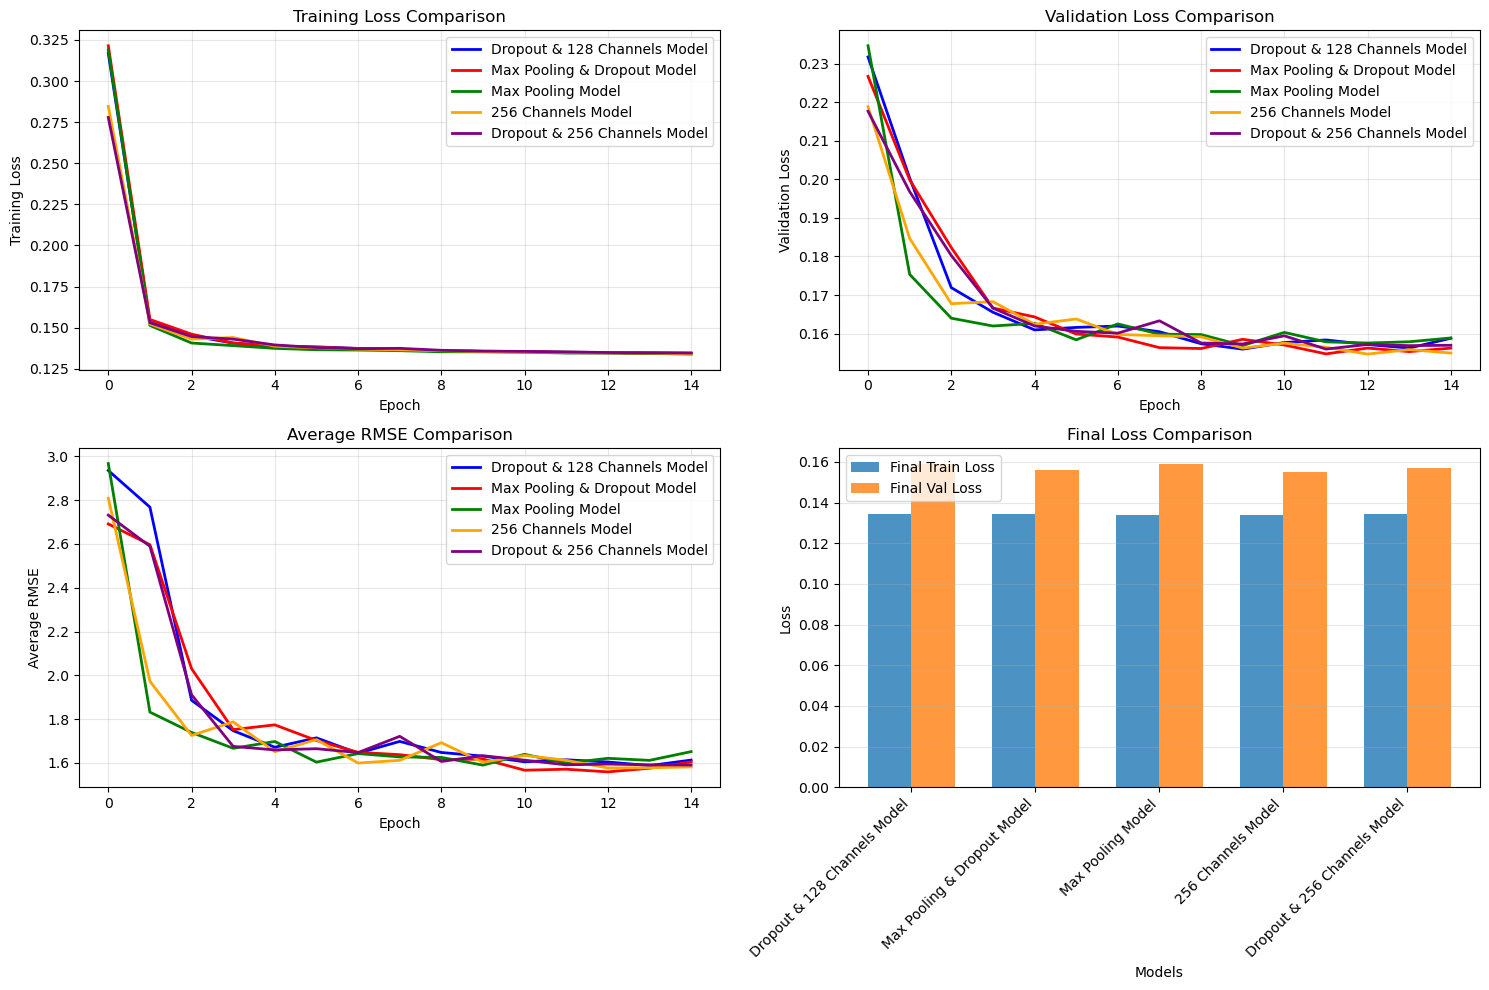

In [16]:
import torch
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path
import numpy as np

def load_and_plot_training_histories(models_folder='Models'):
    """
    Load all model checkpoints from the specified folder and plot their training histories.
    """
    # Get all .pth files in the Models folder
    model_files = glob.glob(os.path.join(models_folder, '*.pth'))
    
    loaded_histories = {}
    
    for i, model_file in enumerate(model_files):
        try:
            checkpoint = torch.load(model_file, map_location='cpu', weights_only=False)
        except:
            from collections import defaultdict
            torch.serialization.add_safe_globals([defaultdict])
            checkpoint = torch.load(model_file, map_location='cpu')
        
        history = checkpoint['history']
        model_name = os.path.basename(model_file).replace('.pth', '')
        model_name = model_name[21:-11].replace('dropout','Dropout').replace('_channel',' Channels').replace('max','Max Pooling').replace('_',' & ') + ' Model'
        
        loaded_histories[model_name] = history
    
    return loaded_histories

def plot_model_comparison(loaded_histories, save_path='model_comparison.png'):
    """
    Create comparison plots showing all models on the same axes and save as PNG.
    """
    if len(loaded_histories) < 2:
        print("Need at least 2 models for comparison plots")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    # Plot 1: Training Loss Comparison
    for i, (model_name, history) in enumerate(loaded_histories.items()):
        color = colors[i % len(colors)]
        axes[0, 0].plot(history['train_loss'], label=model_name, color=color, linewidth=2)
    
    axes[0, 0].set_title('Training Loss Comparison')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Training Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Validation Loss Comparison
    for i, (model_name, history) in enumerate(loaded_histories.items()):
        color = colors[i % len(colors)]
        axes[0, 1].plot(history['val_loss'], label=model_name, color=color, linewidth=2)
    
    axes[0, 1].set_title('Validation Loss Comparison')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Validation Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Average RMSE Comparison
    for i, (model_name, history) in enumerate(loaded_histories.items()):
        if 'metrics' in history:
            rmse_metrics = [values for key, values in history['metrics'].items() 
                          if 'rmse' in key and 'mean_rmse' not in key]
            if rmse_metrics:
                avg_rmse = np.mean(rmse_metrics, axis=0)
                color = colors[i % len(colors)]
                axes[1, 0].plot(avg_rmse, label=model_name, color=color, linewidth=2)
    
    axes[1, 0].set_title('Average RMSE Comparison')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Average RMSE')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Final Loss Comparison Bar Chart
    model_names = list(loaded_histories.keys())
    final_train_losses = [history['train_loss'][-1] for history in loaded_histories.values()]
    final_val_losses = [history['val_loss'][-1] for history in loaded_histories.values()]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    axes[1, 1].bar(x - width/2, final_train_losses, width, label='Final Train Loss', alpha=0.8)
    axes[1, 1].bar(x + width/2, final_val_losses, width, label='Final Val Loss', alpha=0.8)
    
    axes[1, 1].set_title('Final Loss Comparison')
    axes[1, 1].set_xlabel('Models')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Plot saved as: {save_path}")
    
    plt.show()
histories = load_and_plot_training_histories('Models')
plot_model_comparison(histories, save_path='model_comparison.png')

Plot saved as: 256_channels_simple.png


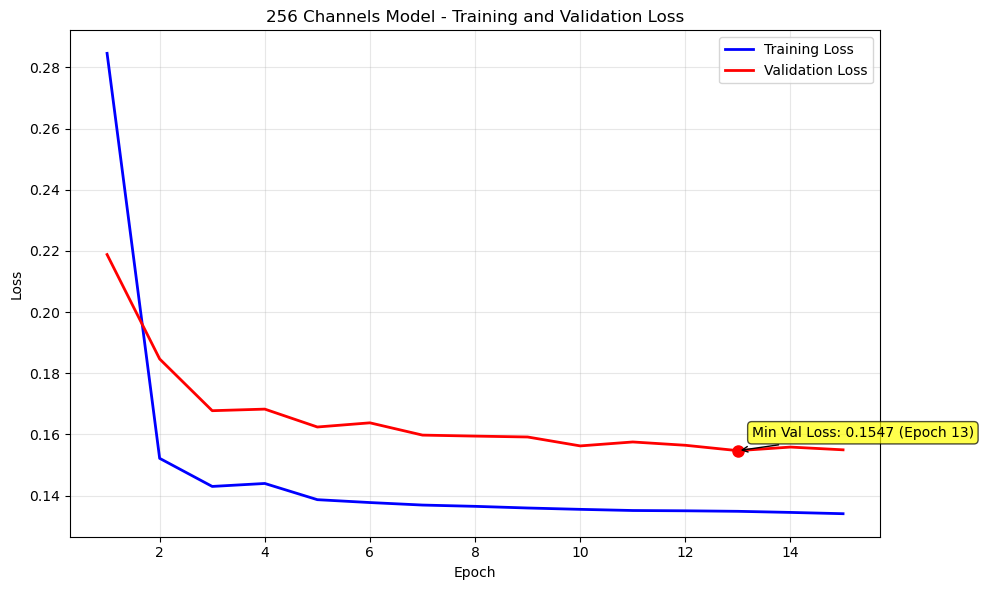

In [17]:
def plot_simple_loss_history(loaded_histories, model_name, save_path=None):
    """
    Simple plot showing only training and validation loss on the same chart.
    """
    if model_name not in loaded_histories:
        print(f"Model '{model_name}' not found in loaded histories")
        print(f"Available models: {list(loaded_histories.keys())}")
        return
    
    history = loaded_histories[model_name]
    
    plt.figure(figsize=(10, 6))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add min validation loss point
    min_val_loss_epoch = np.argmin(history['val_loss']) + 1
    min_val_loss = min(history['val_loss'])
    plt.plot(min_val_loss_epoch, min_val_loss, 'ro', markersize=8)
    plt.annotate(f'Min Val Loss: {min_val_loss:.4f} (Epoch {min_val_loss_epoch})',
                xy=(min_val_loss_epoch, min_val_loss),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
plot_simple_loss_history(histories, '256 Channels Model', save_path='256_channels_simple.png')


In [42]:
model.eval()

all_preds = []
all_targets = []

val_loss = 0

with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        val_loss += loss.item()

        all_preds.append(pred.cpu())
        all_targets.append(yb.cpu())

print(f'Final Normalized Validation Loss: {val_loss / len(val_loader):.4f}')

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

all_preds = normalizer.inverse_transform_output(all_preds.detach().cpu().numpy())
all_targets = normalizer.inverse_transform_output(all_targets.detach().cpu().numpy())

for i, var in enumerate(output_vars):
    p = all_preds[:, i]
    t = all_targets[:, i]

    p_xr = xr.DataArray(p, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
    t_xr = xr.DataArray(t, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
    
    rmse = np.sqrt(((p_xr - t_xr) ** 2).weighted(area_weights).mean(("time", "y", "x")).item())
    mean_rmse = np.sqrt(((p_xr.mean("time") - t_xr.mean("time")) ** 2).weighted(area_weights).mean(("y", "x")).item())
    std_mae = np.abs(p_xr.std("time") - t_xr.std("time")).weighted(area_weights).mean(("y", "x")).item()

    print(f"{var}: RMSE={rmse:.4f}, Time-Mean RMSE={mean_rmse:.4f}, Time-Stddev MAE={std_mae:.4f}")

Final Normalized Validation Loss: 0.1566
tas: RMSE=1.3095, Time-Mean RMSE=0.4371, Time-Stddev MAE=0.1993
pr: RMSE=1.9702, Time-Mean RMSE=0.1514, Time-Stddev MAE=0.7271


In [44]:
print(pred_np.shape)


(32, 2, 48, 72)


In [52]:
def plot_comparison(true_xr, pred_xr, title, cmap='viridis', diff_cmap='RdBu_r', metric=None, save_path = None):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    vmin = min(true_xr.min().item(), pred_xr.min().item())
    vmax = max(true_xr.max().item(), pred_xr.max().item())

    # Ground truth
    true_xr.plot(ax=axs[0], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    axs[0].set_title(f"{title} (Ground Truth)")

    # Prediction
    pred_xr.plot(ax=axs[1], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    axs[1].set_title(f"{title} (Prediction)")

    # Difference
    diff = pred_xr - true_xr
    abs_max = np.max(np.abs(diff))
    diff.plot(ax=axs[2], cmap=diff_cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=True)
    # axs[2].set_title(f"{title} (Difference) {f'- {metric:.4f}' if metric else ''}")
    axs[2].set_title(f"{title} (Difference)")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
    else:
        plt.show()
    plt.show()

In [56]:
def plot_comparison_shared_plot(true_xr, pred_xr, title, axs, cmap='viridis', diff_cmap='RdBu_r', metric=None):
    vmin = min(true_xr.min().item(), pred_xr.min().item())
    vmax = max(true_xr.max().item(), pred_xr.max().item())

    # Ground truth
    true_xr.plot(ax=axs_row[0], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    axs_row[0].set_title(f"{title} (GT)")

    # Prediction
    pred_xr.plot(ax=axs_row[1], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    axs_row[1].set_title(f"{title} (Pred)")

    # Difference
    diff = pred_xr - true_xr
    abs_max = np.max(np.abs(diff))
    diff.plot(ax=axs_row[2], cmap=diff_cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=True)
    axs_row[2].set_title(f"{title} (Diff)")


In [59]:
top_k = 2
output_dir = "worst_preds_pngs"
os.makedirs(output_dir, exist_ok=True)
worst_idxs = np.argsort(val_errors)[-top_k:]
lat = spatial_template.y.values
lon = spatial_template.x.values
n_vars = len(output_vars)
n_rows = top_k * n_vars
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
if n_rows == 1:
    axs = np.expand_dims(axs, axis=0)
if n_cols == 1:
    axs = np.expand_dims(axs, axis=1)

for i, idx in enumerate(worst_idxs):
    for j, var in enumerate(output_vars):
        row_idx = i * n_vars + j
        pred_sample = sample_preds[idx][j]
        true_sample = sample_targets[idx][j]

        pred_xr = xr.DataArray(pred_sample, dims=["y", "x"], coords={"y": lat, "x": lon})
        true_xr = xr.DataArray(true_sample, dims=["y", "x"], coords={"y": lat, "x": lon})

        title = f"Sample #{idx} | Var: {var}"
        plot_comparison_shared_plot(true_xr, pred_xr, title, axs[row_idx])

# Save final image
plt.tight_layout()
save_path = os.path.join(output_dir, "combined_worst_preds.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.close()

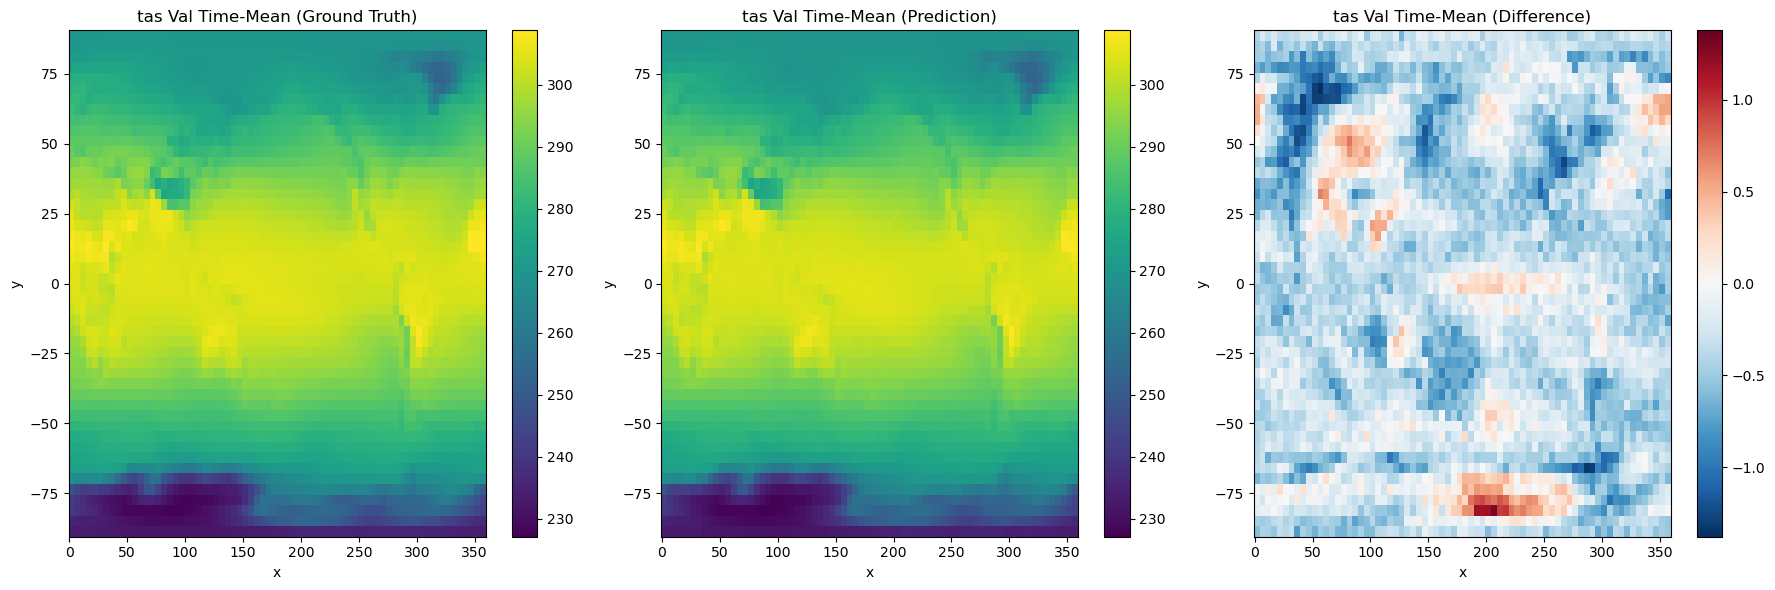

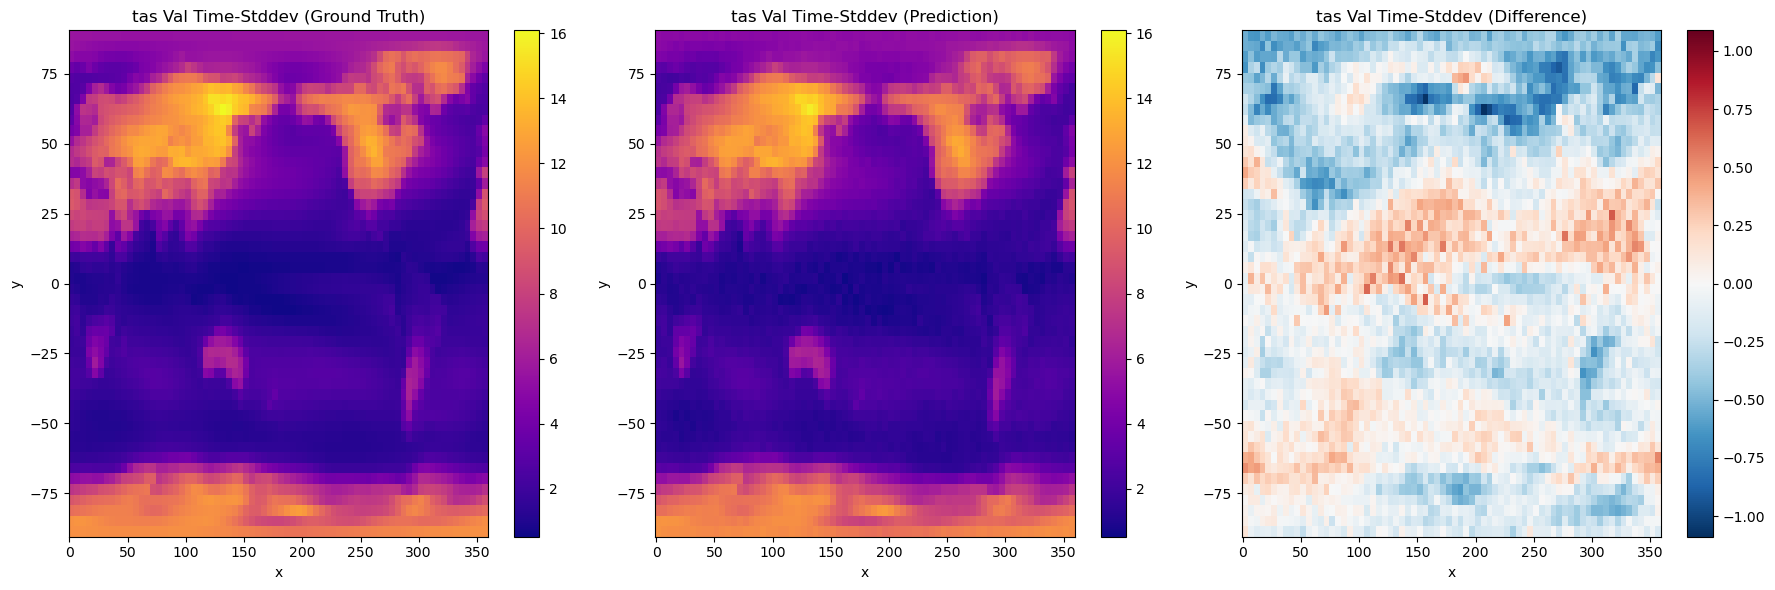

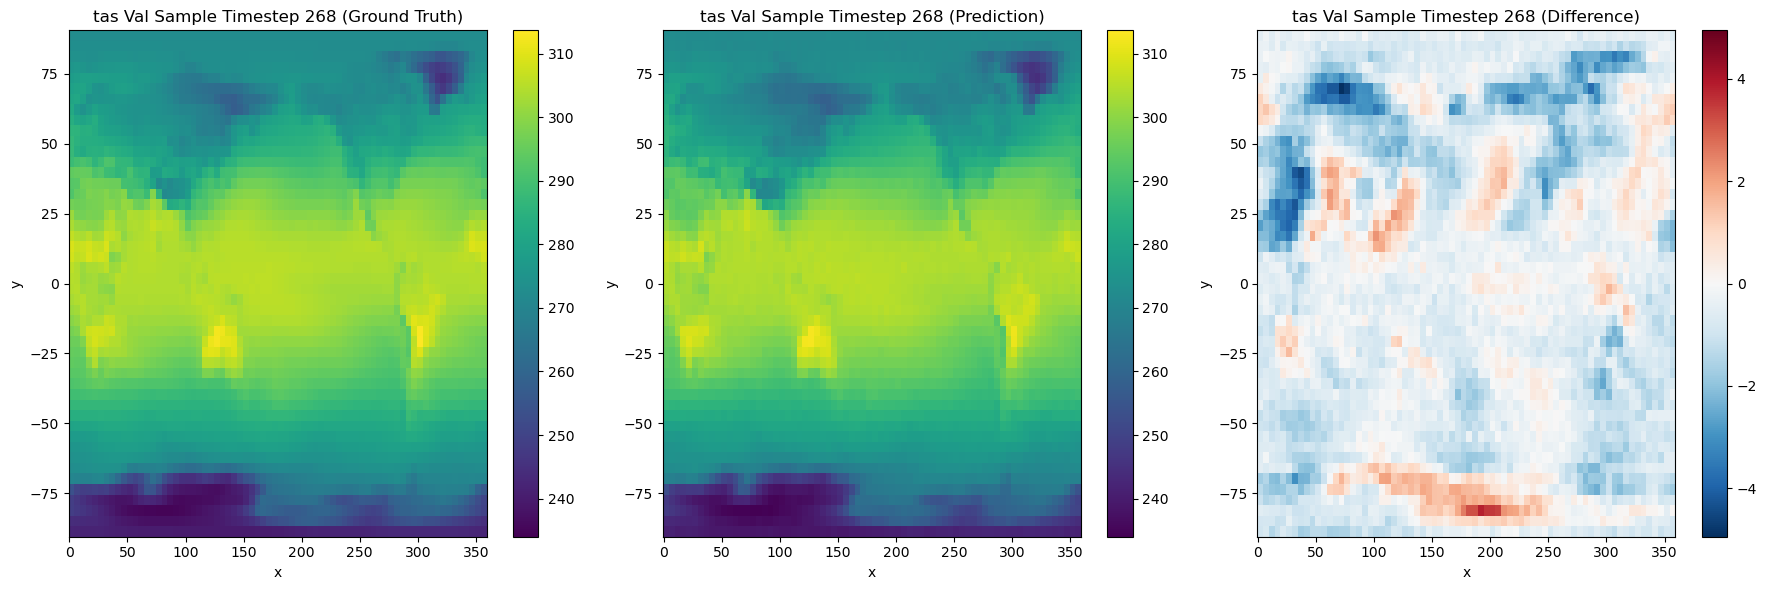

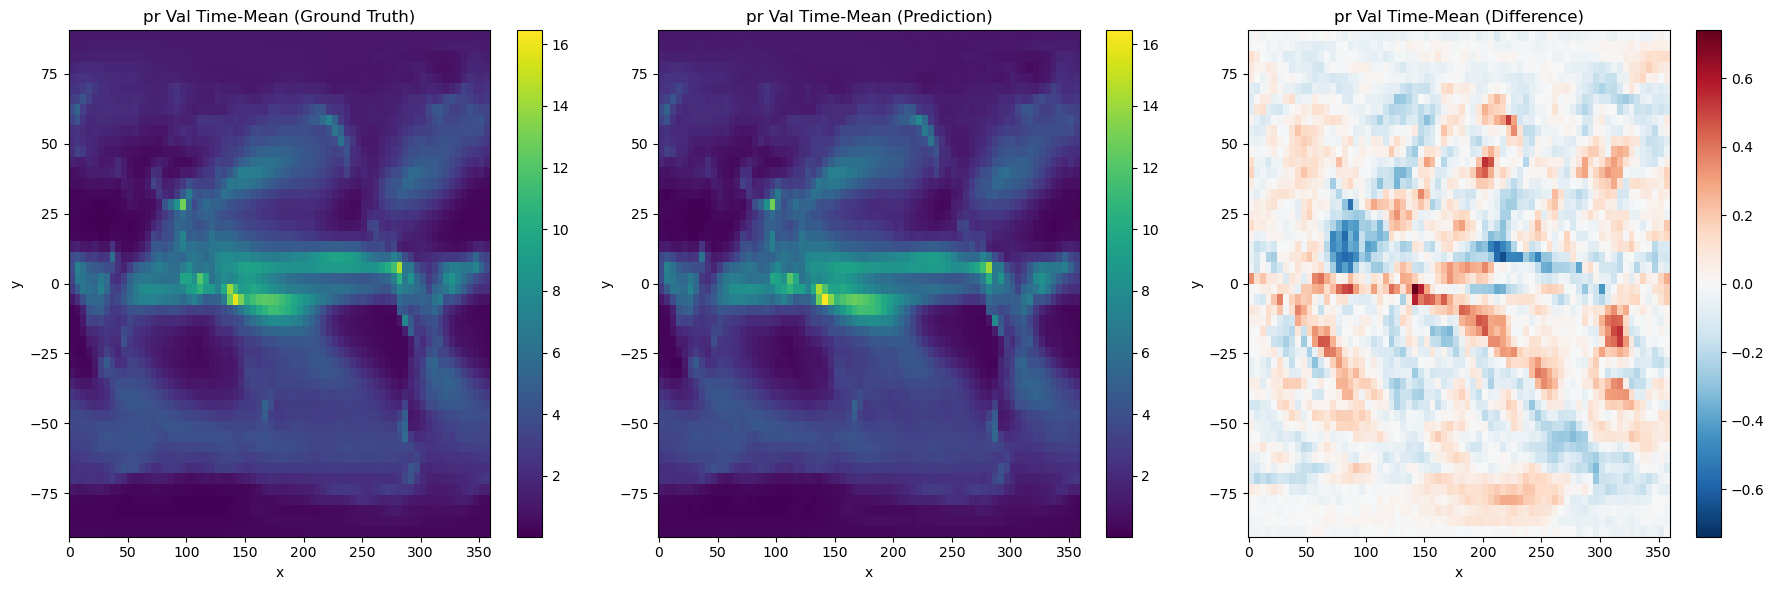

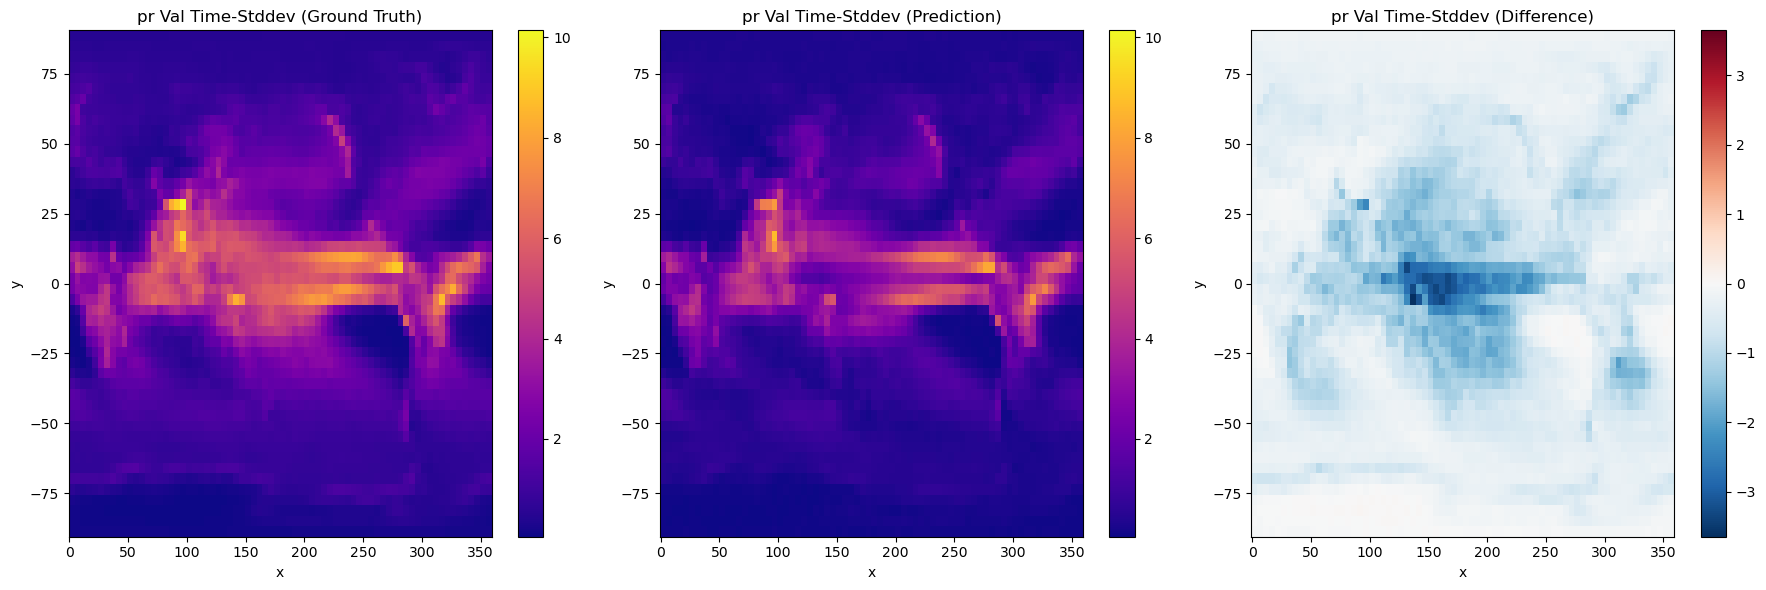

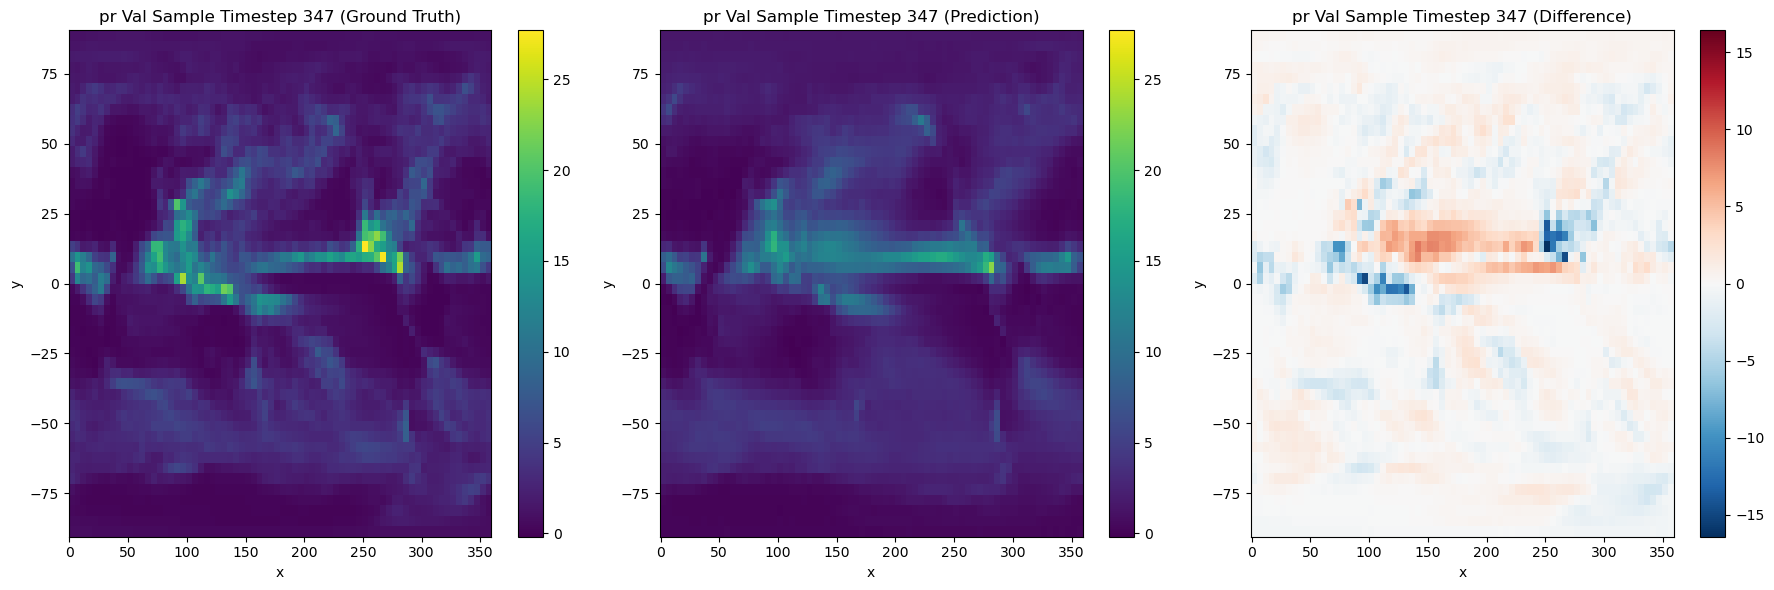

In [54]:
lat = spatial_template.y.values
lon = spatial_template.x.values
time = np.arange(all_preds.shape[0])

for i, var in enumerate(output_vars):
    pred_xr = xr.DataArray(all_preds[:, i], dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
    true_xr = xr.DataArray(all_targets[:, i], dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})

    # --- Time Mean ---
    plot_comparison(true_xr.mean("time"), pred_xr.mean("time"), f"{var} Val Time-Mean")

    # --- Time Stddev ---
    plot_comparison(true_xr.std("time"), pred_xr.std("time"), f"{var} Val Time-Stddev", cmap="plasma")

    # --- Random timestep ---
    t_idx = np.random.randint(0, len(time))
    plot_comparison(true_xr.isel(time=t_idx), pred_xr.isel(time=t_idx), f"{var} Val Sample Timestep {t_idx}")

In [26]:
model.eval()

test_predictions = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_dataloader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        test_predictions.append(pred.cpu())
        test_targets.append(yb.cpu())

test_predictions = torch.cat(test_predictions, dim=0)
test_targets = torch.cat(test_targets, dim=0)

test_predictions = normalizer.inverse_transform_output(test_predictions.detach().cpu().numpy())
test_targets = normalizer.inverse_transform_output(test_targets.detach().cpu().numpy())

In [27]:
lat = spatial_template.y.values
lon = spatial_template.x.values
time = np.arange(test_predictions.shape[0])

rows = []
for t_idx, t in enumerate(time):
    for var_idx, var in enumerate(output_vars):
        for y_idx, y in enumerate(lat):
            for x_idx, x in enumerate(lon):
                row_id = f"t{t_idx:03d}_{var}_{y:.2f}_{x:.2f}"
                pred = test_predictions[t_idx, var_idx, y_idx, x_idx]
                rows.append({"ID": row_id, "Prediction": pred})

df = pd.DataFrame(rows)
os.makedirs("submissions", exist_ok=True)
filepath = f"submissions/kaggle_submission_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df.to_csv(filepath, index=False)
print(f"✅ Submission saved to: {filepath}")

✅ Submission saved to: submissions/kaggle_submission_20250523_191955.csv
